# SentimentScope: Sentiment Analysis using Transformers!
## Introduction <a name = "introduction"></a>

In this notebook, you will train a transformer model from scratch to perform sentiment analysis on the IMDB dataset. You are a Machine Learning Engineer at Cinescope, a growing entertainment company working to enhance its recommendation system. Your task is to fine-tune a transformer-based model for sentiment analysis using the IMDB dataset. By classifying reviews as positive or negative, you will help the company better understand user sentiment and deliver more personalized experiences.

By completing this project, you will demonstrate your competency in the following learning objectives:

- Load, explore, and prepare a text dataset for training a transformer model using PyTorch.
- Customize the architecture of the transformer model for a classification task.
- Train and test a transformer model on the IMDB dataset.

Now that you have an overview of what you will achieve in this project, let’s move on to the project outline.

---

### Project Outline

This notebook is organized into the following sections:


1. [Introduction](#introduction): Overview of the project, learning objectives, and understanding sentiment analysis.
2. [Load, Explore, and Prepare the Dataset](#load-explore-and-prepare-the-dataset): Load the IMDB dataset, explore it with visualizations, and split it into training and validation sets.
3. [Implement a DataLoader in PyTorch](#implement-a-dataloader-in-pytorch): Create the `IMDBDataset` class and use it with the PyTorch `DataLoader`, including tokenization.
4. [Customize the Transformer Architecture](#customize-the-transformer-architecture): Modify the transformer model for binary classification.
5. [Implement Accuracy Calculation Method](#implement-accuracy-calculation-method): Create a function to compute accuracy for monitoring performance.
6. [Train the Model](#train-the-model): Complete and execute the training loop for binary classification.
7. [Test the Model](#test-the-model): Evaluate the model on the test dataset and ensure it achieves over 75% accuracy.
8. [Conclusion](#conclusion): Summarize the project results and key takeaways.

Click on the section titles above to navigate directly to the corresponding part of the notebook!

---

Now that we've outlined the structure and objectives of this project, let's delve into the core concept: sentiment analysis.

### Understanding Sentiment Analysis

Sentiment analysis is a natural language processing (NLP) technique used to determine the sentiment expressed in a piece of text. This can range from identifying the polarity (positive, negative, or neutral) of a review to analyzing emotions and opinions.

In this project, sentiment analysis is explicitly framed as a **binary classification task**, where the goal is to determine whether a given movie review is *positive* or *negative*. This task is central to many real-world applications, including customer feedback analysis, social media monitoring, and recommendation systems. By developing a transformer-based model, you will classify IMDB movie reviews as positive or negative to tackle the challenge faced by your entertainment company CineScope by enhancing its recommendation system, enabling more accurate and personalized suggestions. 

Reviews labeled as positive will be marked as 1 in the dataset, while negative reviews will be labeled as 0.

For example, consider the following movie review:

> "The movie was a rollercoaster of emotions, and I loved every moment of it!"

This review is clearly positive as it expresses enjoyment and satisfaction with the movie, hence it will be labelled as *positive* or 1 in the dataset. In contrast:

> "The plot was predictable, and the acting was subpar. A waste of time."

This review conveys a negative sentiment, criticizing both the plot and acting, hence it will be labelled as *negative* or 0 in the dataset.

While transformers are often used for generation tasks, they can also be adapted for classification tasks with some modifications to their architecture. You might already be familiar with the tweaks that we will implement in this project.


---

### Data Description

The dataset used in this project is the [IMDB dataset](https://ai.stanford.edu/~amaas/data/sentiment/), provided in the `aclIMDB_v1.tar.gz` file. Upon extracting the file, you will find the following folder structure:

```
aclIMDB/
├── train/
│   ├── pos/    # Positive reviews for training
│   ├── neg/    # Negative reviews for training
│   ├── unsup/  # Unsupervised data (not used in this project)
├── test/
│   ├── pos/    # Positive reviews for testing
│   ├── neg/    # Negative reviews for testing
```

- **train/**: Contains labeled data for training the model. Reviews in the `pos/` folder should be labeled as positive (1), while reviews in the `neg/` folder should be labeled as negative (0).
- **test/**: Contains labeled data for evaluating the model. Similar to the training data, `pos/` and `neg/` contain positive and negative reviews, respectively.
- **unsup/**: Contains unlabeled reviews that are not used in this project.

Understanding the folder structure is crucial as it guides how we load and preprocess the data for the sentiment classification task.

---


## <a name="load-explore-and-prepare-the-dataset"></a>Load, Explore, and Prepare the Dataset

### 1. Load the Dataset
The dataset is already available in the environment as `aclIMDB_v1.tar.gz`. We will load it into Pandas DataFrames for easy exploration and preparation.


In [1]:
import os
import time
import pandas as pd

NOTEBOOK_T0 = time.perf_counter()

In [2]:
# Unpack the dataset - uncomment the line below to run
# !tar -xzf aclImdb_v1.tar.gz

You have successfully extracted the folder. Go back to your workspace and explore the folder structure and find the relative paths for each of the following:
- Training positive reviews
- Training negative reviews
- Testing positive reviews
- Testing negative reviews

Assign the paths of these folders relative to the starter file in the variables below.


In [3]:
# Define paths to dataset
train_pos_path = 'aclImdb/train/pos'
train_neg_path = 'aclImdb/train/neg'
test_pos_path = 'aclImdb/test/pos'
test_neg_path = 'aclImdb/test/neg'

Now, you will implement the `load_dataset()` function, which reads all text files in a specified folder and returns their content as a list of strings. This function is essential for loading and preprocessing the dataset in subsequent steps.

To implement this function:

1. **Use the `os` module**: Leverage Python's `os` module to list all files in the folder.
2. **Handle file paths**: Use `os.path.join()` to construct full paths for files, ensuring compatibility across operating systems.
3. **Read file content**: Open each file in read mode (`'r'`) using UTF-8 encoding to handle text properly.
4. **Aggregate results**: Append the content of each file to a list and return it.

### Key Points to Consider:
- Ensure that the function only processes text files (you may use file extensions for filtering if needed).
- Refer to the [os.listdir documentation](https://docs.python.org/3/library/os.html#os.listdir) for listing files in a directory.


In [4]:
def load_dataset(folder):
    """
    Reads all text files in the specified folder and returns their content as a list.

    Args:
        folder (str): Path to the folder containing text files.

    Returns:
        list: A list of strings, where each string is the content of a text file.
    """
    texts = []
    for filename in os.listdir(folder):
        if filename.endswith(".txt"):
            filepath = os.path.join(folder, filename)
            with open(filepath, "r", encoding="utf-8") as f:
                texts.append(f.read())
    return texts

Use the function now to load the training and testing data:

In [5]:
# Load training and testing data
train_pos = load_dataset(train_pos_path)
train_neg = load_dataset(train_neg_path)
test_pos = load_dataset(test_pos_path)
test_neg = load_dataset(test_neg_path)

We can convert the data into pandas dataframes to make handling the datasets easier.

In [6]:
# Create DataFrames
train_df = pd.DataFrame({
    'review': train_pos + train_neg,
    'label': [1] * len(train_pos) + [0] * len(train_neg)
})

test_df = pd.DataFrame({
    'review': test_pos + test_neg,
    'label': [1] * len(test_pos) + [0] * len(test_neg)
})

print(train_df.head())

                                              review  label
0  As an aging rocker, this movie mentions Heep a...      1
1  And that's why historic/biographic movies are ...      1
2  If you want Scream or anything like the big-st...      1
3  The quote I used for my summary occurs about h...      1
4  I remember this movie from when i was 12, it w...      1


You can ensure that your datasets have loaded correctly by running the following code cell. No output means success!

In [7]:
# Assert that both datasets have the expected number of rows
assert train_df.shape[0] == 25000, "Training dataset does not have 25000 rows."
assert test_df.shape[0] == 25000, "Testing dataset does not have 25000 rows."

# Assert that both datasets have exactly two columns
assert train_df.shape[1] == 2, "Training dataset does not have exactly 2 columns."
assert test_df.shape[1] == 2, "Testing dataset does not have exactly 2 columns."


In [8]:
# Max tokens per sequence (tokenizer, dataset, model context_size) — run after loading train_df
MAX_LENGTH = 384


### 2. Explore the Dataset
Exploration helps us understand the dataset's structure and distribution.

Here are some suggestions for exploration and visualizations:
- **Dataset Overview**: Use `DataFrame.info()` and `DataFrame.describe()` to understand the dataset structure and basic statistics.
- **Label Distribution**: Create bar charts to visualize the number of positive and negative reviews.
- **Review Length Analysis**: Compute and plot the distribution of review lengths (e.g., number of characters or words).
- **Sample Reviews**: Print a few positive and negative reviews to understand the text content.

Write code to explore the dataset in this section.

In [9]:
import matplotlib.pyplot as plt

# Dataset overview
print("=== Training Set ===")
print(train_df.info())
print("\n", train_df.describe())

print("\n=== Test Set ===")
print(test_df.info())
print("\n", test_df.describe())

=== Training Set ===
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 390.8 KB
None

              label
count  25000.00000
mean       0.50000
std        0.50001
min        0.00000
25%        0.00000
50%        0.50000
75%        1.00000
max        1.00000

=== Test Set ===
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 390.8 KB
None

              label
count  25000.00000
mean       0.50000
std        0.50001
min        0.00000
25%        0.00000
50%        0.50000
75%        1.00000
max        1.00000


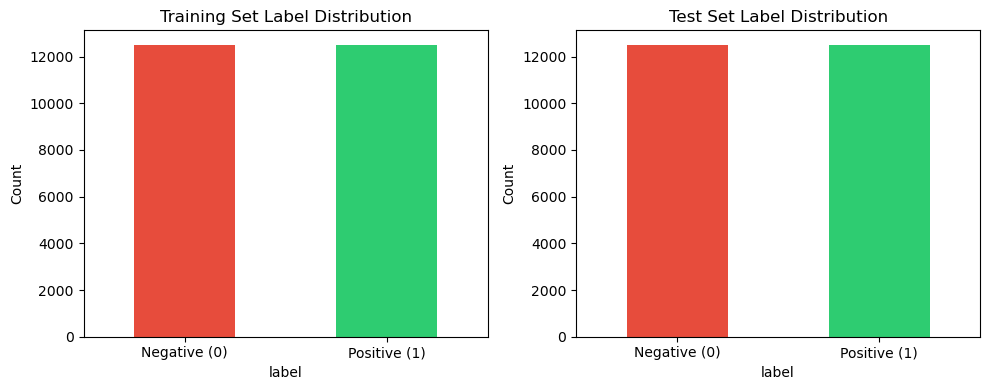

Train: {1: 12500, 0: 12500}
Test:  {1: 12500, 0: 12500}


In [10]:
# Label distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

train_df['label'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Training Set Label Distribution')
axes[0].set_xticklabels(['Negative (0)', 'Positive (1)'], rotation=0)
axes[0].set_ylabel('Count')

test_df['label'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Test Set Label Distribution')
axes[1].set_xticklabels(['Negative (0)', 'Positive (1)'], rotation=0)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Train: {train_df['label'].value_counts().to_dict()}")
print(f"Test:  {test_df['label'].value_counts().to_dict()}")

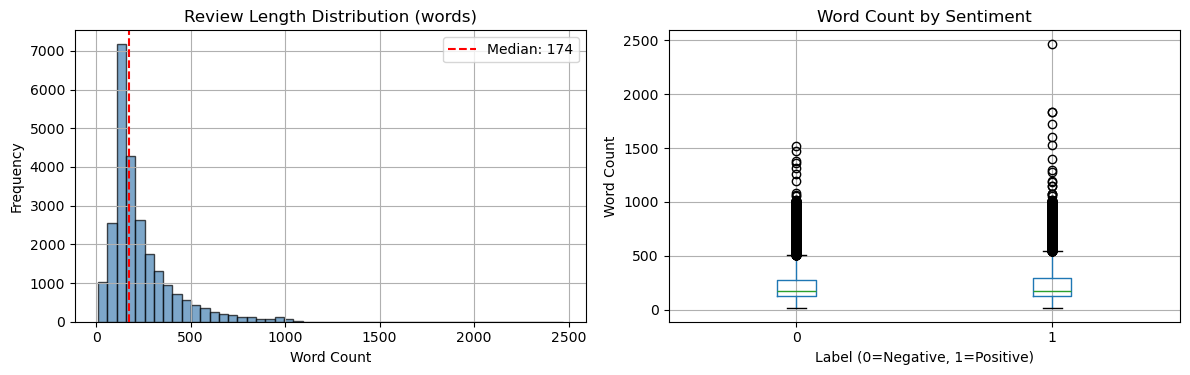

Word count stats:
count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: word_count, dtype: float64

Reviews > 384 words: 3614 (14.5%)


In [11]:
# Review length analysis (word count)
train_df['word_count'] = train_df['review'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df['word_count'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Review Length Distribution (words)')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(train_df['word_count'].median(), color='red', linestyle='--', label=f"Median: {train_df['word_count'].median():.0f}")
axes[0].legend()

train_df.boxplot(column='word_count', by='label', ax=axes[1])
axes[1].set_title('Word Count by Sentiment')
axes[1].set_xlabel('Label (0=Negative, 1=Positive)')
axes[1].set_ylabel('Word Count')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f"Word count stats:\n{train_df['word_count'].describe()}")
print(f"\nReviews > {MAX_LENGTH} words: {(train_df['word_count'] > MAX_LENGTH).sum()} "
      f"({(train_df['word_count'] > MAX_LENGTH).mean()*100:.1f}%)")

train_df.drop(columns=['word_count'], inplace=True)

In [12]:
# Sample reviews
print("=== Sample POSITIVE Reviews ===\n")
for i, row in train_df[train_df['label'] == 1].sample(2, random_state=42).iterrows():
    print(f"[{len(row['review'].split())} words] {row['review'][:300]}...\n")

print("=== Sample NEGATIVE Reviews ===\n")
for i, row in train_df[train_df['label'] == 0].sample(2, random_state=42).iterrows():
    print(f"[{len(row['review'].split())} words] {row['review'][:300]}...\n")

=== Sample POSITIVE Reviews ===

[97 words] When an orphanage manager goes on vacation, his father takes over the details of the center and winds up renting the kids. When a well off, got it made couple with a nice apartment and great life get the notion to adopt this idea was tailor made for them. Why would they want to spoil their elegant e...

[170 words] John Garfield plays a Marine who is blinded by a grenade while fighting on Guadalcanal and who has to learn to live with his disability. He has all the stereotypical notions about blindness, and is sure he'll be a burden to everyone. The hospital staff and his fellow wounded Marines can't get throug...

=== Sample NEGATIVE Reviews ===

[211 words] This is the kind of film one watches in gape-jawed, horrified silence, and yet continues to watch, mesmerized, as if watching a train wreck in slow motion. And yet, in the back of your mind, thoughts are churning: "Who on EARTH green-lighted this garbage?"<br /><br />Some of the preceding

### 3. Prepare the Dataset
We will split the training data further into training and validation subsets. The way we constructed the dataset, reviews with positive and negative labels are segregated. To ensure that the validation dataset works well, we first need to shuffle the dataset.


In [13]:
# Split train data into training and validation sets manually
train_size = int(0.9 * len(train_df))
# Shuffle the dataset
shuffled_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_data = shuffled_df.iloc[:train_size]
val_data = shuffled_df.iloc[train_size:]

### 4. Testing the Tokenizer

#### Subword Tokenization
In earlier tasks, you might have encountered character-level tokenization, where each character in the text is treated as a token. While this is straightforward, it is less efficient and may result in larger input sizes, impacting the performance of transformer models.

To address this, we will use Hugging Face's `AutoTokenizer`, a robust and efficient class designed for tokenizing text based on pretrained models. Specifically, we will utilize the `bert-base-uncased` tokenizer, which applies **subword tokenization**. Subword tokenization involves two steps:

1. **Subword Splitting**: Words are split into smaller components (subwords) based on a predefined vocabulary. For example:
   - Input: "unhappiness"
   - Subword Splits: `['un', 'happiness']`

2. **Token Conversion**: Each subword is then converted into a numerical token ID. For example:
   - Subword Splits: `['un', 'happiness']`
   - Token IDs: `[1011, 24123]` (values are illustrative and depend on the tokenizer vocabulary).

#### About the `bert-base-uncased` Tokenizer
The `bert-base-uncased` tokenizer, developed by Google researchers, is part of the BERT model family. This tokenizer is associated with the `bert-base-uncased` model, which has been widely used for tasks such as sentiment analysis, question answering, and text classification. The tokenizer ensures all text is converted to lowercase and accents are removed, reducing vocabulary size and improving generalization. Example:

- Input: "I Love Transformers."
- Subword Splits: `['i', 'love', 'trans', '##formers', '.']`

You can learn more about the tokenizer and model on [Hugging Face's bert-base-uncased page](https://huggingface.co/bert-base-uncased).

#### Using the `AutoTokenizer` Class
The `AutoTokenizer` class in the Hugging Face Transformers library provides a seamless way to load tokenizers for various pretrained models. It automatically selects the correct tokenizer configuration based on the model name.


In [14]:
from transformers import AutoTokenizer

MAX_LENGTH = globals().get("MAX_LENGTH", 384)

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

This initializes a tokenizer tailored for the `bert-base-uncased` model. You can refer to the [Hugging Face AutoTokenizer documentation](https://huggingface.co/docs/transformers/main_classes/tokenizer) for more details. You can find the definition of the `from_pretrained()` method [here](https://huggingface.co/docs/transformers/v4.48.0/en/model_doc/auto#transformers.AutoTokenizer.from_pretrained).

Instead of tokenizing the entire dataset, we will test the tokenizer on a few sample reviews directly from the dataset:


In [15]:
# Take sample inputs from the dataset
sample_texts = train_data['review'].sample(3, random_state=42).tolist()

# Tokenize sample inputs
tokenized_samples = tokenizer(sample_texts, truncation=True, padding="max_length", max_length=MAX_LENGTH, return_tensors="pt")

In [16]:
print(tokenized_samples)

{'input_ids': tensor([[ 101, 2023, 3185,  ...,    0,    0,    0],
        [ 101, 1045, 2034,  ...,    0,    0,    0],
        [ 101, 4214, 2023,  ...,    0,    0,    0]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])}


Explanation of parameters:
 - `truncation=True`: Truncates text longer than the specified max_length.
 - `padding=True`: Pads shorter sequences to match max_length.
 - `max_length=128`: Specifies the maximum length of the sequences.
 - `return_tensors="pt"`: Returns PyTorch tensors as the output format.
 
For more details about truncation and padding, refer to the [Hugging Face Padding and Truncation Documentation](https://huggingface.co/docs/transformers/pad_truncation). This step ensures that the tokenizer works as expected and provides insight into its behavior. Next, we will use the tokenizer within the class definition to process the dataset.

---


# Implement a DataLoader in PyTorch<a id="implement-a-dataloader-in-pytorch"></a>


In this section, you will implement a custom dataset class and use it to create a DataLoader in PyTorch for feeding data into the model during training. PyTorch simplifies this process by providing the `Dataset` and `DataLoader` classes, which handle batching, shuffling, and preprocessing, allowing you to focus on the model architecture and training.

To start, we will create a custom dataset class for the IMDB dataset, which will process and return tokenized inputs along with their corresponding labels. This class will use a tokenizer to preprocess the raw text data.

### 1. Define a Custom Dataset Class

The custom dataset class will inherit from `torch.utils.data.Dataset` and include the following features:

1. **Initialization (`__init__`)**:
   - Accepts raw text and label data, along with a tokenizer and a maximum sequence length.
   - The tokenizer is used to preprocess the text data into tokenized inputs.
   - The maximum sequence length ensures that all tokenized inputs are of uniform length.

2. **Length (`__len__`)**:
   - Returns the total number of data samples in the dataset.

3. **Item Retrieval (`__getitem__`)**:
   - Retrieves a single data point by index.
   - Preprocesses the text using the tokenizer to create tokenized input IDs.
   - Returns the tokenized input IDs and the corresponding label for the given index.

You can refer to [this](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) tutorial on the Pytorch website for more details.


In [17]:
import torch
import random
from torch.utils.data import Dataset

USE_RANDOM_DELETION = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 4080 Laptop GPU


**NOTE ABOUT GPU USAGE**

The workspace provides you with access to a GPU which is necessary for training a transformer model due to the efficiency provided by GPUs on the large amount of computations that are required. To ensure judicious usage of limited resources, please usage the GPU only when you are training the model. 

---
I increased `MAX_LENGTH` to 384 tokens (from the original 128) — this captures more of each review and was one of the biggest accuracy improvements (+3–4%). Random word deletion is enabled as a training augmentation.

In [18]:
def random_deletion(text, max_length):
    """Randomly delete words with probability proportional to review length."""
    words = text.split()
    if len(words) <= 1:
        return text
    n = len(words)
    p = min(0.3, (n / max_length) * 0.3)
    remaining = [w for w in words if random.random() > p]
    if len(remaining) == 0:
        return random.choice(words)
    return " ".join(remaining)


def trim_middle_to_fit(text, tokenizer, max_length):
    """When text exceeds max_length tokens, keep first half + last half of words, dropping the middle."""
    words = text.split()
    if len(words) <= 1:
        return text
    n_tokens = len(tokenizer.encode(text, add_special_tokens=True))
    if n_tokens <= max_length:
        return text
    target_words = max(1, int(len(words) * max_length / n_tokens * 0.95))
    head_len = target_words // 2
    tail_len = target_words - head_len
    if head_len + tail_len >= len(words):
        return text
    return " ".join(words[:head_len] + words[-tail_len:])

In [19]:
from torch.utils.data import Dataset

class IMDBDataset(Dataset):
    """
    A custom PyTorch Dataset for the IMDB dataset.

    Returns (input_ids, attention_mask, label) per sample.
    Optionally applies random word deletion augmentation during training.
    Uses trim_middle_to_fit for reviews that exceed MAX_LENGTH tokens.
    """
    def __init__(self, data, tokenizer, max_length=MAX_LENGTH, augment=False):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = self.data.iloc[idx]["review"]
        label = self.data.iloc[idx]["label"]
        if len(self.tokenizer.encode(text, add_special_tokens=True)) > self.max_length:
            text = trim_middle_to_fit(text, self.tokenizer, self.max_length)
        if self.augment:
            text = random_deletion(text, self.max_length)
        tokens = self.tokenizer(
            text, truncation=True, padding="max_length",
            max_length=self.max_length, return_tensors="pt",
        )
        input_ids = tokens["input_ids"].squeeze(0)
        attention_mask = tokens["attention_mask"].squeeze(0)
        return input_ids, attention_mask, label

### 2. Initialize the Dataset

Once the `IMDBDataset` class is defined, we can initialize it directly with the training and validation DataFrames.

In [20]:
# Initialize the datasets (training set uses augmentation)
train_dataset = IMDBDataset(train_data, tokenizer, augment=USE_RANDOM_DELETION)
val_dataset = IMDBDataset(val_data, tokenizer)
test_dataset = IMDBDataset(test_df, tokenizer)

### 3. Create a DataLoader

The `DataLoader` class in PyTorch helps manage batches of data during training. We will use it to create training and validation data loaders.

In [21]:
from torch.utils.data import DataLoader

# Define batch size
BATCH_SIZE = 32

# Create DataLoader instances
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


You may have seen the use of `RandomShuffler` along with `DataLoader`. That approach is used when you want to train a model over a dataset randomly for a specified number of steps. In this model, we want to use the epoch approach.

An **epoch** is one complete pass through the entire dataset. When using the `DataLoader` in this setup, it ensures that every data point in the dataset is used exactly once during a single epoch. This approach is helpful for training models in a structured manner, ensuring that the model sees all the training examples and learns from them in each epoch before moving to the next one.

By setting `shuffle=True` for the `train_loader`, the data points are randomly shuffled at the start of each epoch, improving the generalization of the model. You will see this in action later in the code for training the model.

---
Given below are some assert statements to check your custom dataset and data loader definitions.

In [22]:
assert len(train_dataset) == 22500, "Train dataset length mismatch!"
assert len(val_dataset) == 2500, "Validation dataset length mismatch!"
assert len(test_dataset) == 25000, "Test dataset length mismatch!"

import numpy as np

# Check the first item in the train dataset (now returns 3 items)
input_ids, attention_mask, label = train_dataset[0]
assert isinstance(input_ids, torch.Tensor), "Input IDs should be a torch.Tensor!"
assert isinstance(attention_mask, torch.Tensor), "Attention mask should be a torch.Tensor!"
assert isinstance(label, (int, np.integer)), "Label should be an integer or int-like!"

# Ensure the input IDs tensor has the correct shape
assert input_ids.shape[0] == train_dataset.max_length, "Input IDs tensor has incorrect length!"
assert attention_mask.shape[0] == train_dataset.max_length, "Attention mask has incorrect length!"

## <a id="customize-the-transformer-architecture"></a>Customize the Transformer Architecture

In this section, you will customize the transformer architecture to suit the task of binary classification. You may have used a similar architecture in the past for generation tasks. But you will need to make a few tweaks specifically in the `DemoGPT` class to adapt it for the binary classification.

### 1. Config Dictionary
Your config dictionary bundles all hyperparameters and model settings in one place. Below is the config that we will use in our model:

In [23]:
config = {
    "vocabulary_size": tokenizer.vocab_size,
    "num_classes": 2,
    "d_embed": 256,
    "context_size": MAX_LENGTH,
    "layers_num": 2,
    "heads_num": 4,
    "head_size": 64,  # 4 heads * 64 = 256 -> matches d_embed
    "dropout_rate": 0.186,
    "use_bias": True,
    "use_positional_encoding": True,
}

Key Config Parameters:
- `vocabulary_size`: The total number of tokens in your vocabulary.
- `num_classes`: The number of classes for the classification head (2 = binary).
- `d_embed`: Dimensionality of embeddings (and hidden layers).
- `context_size`: Maximum sequence length for each input.
- `layers_num`: Number of stacked transformer blocks.
- `heads_num`: Number of attention heads in multi-head attention.
- `head_size`: Dimension of each attention head (must satisfy heads_num * head_size = d_embed).
- `dropout_rate`: Probability of dropping units during training to reduce overfitting.
- `use_bias`: Whether linear layers should have bias terms.



### 2. Class Definitions

Below are the class definitions you will work with. These classes form the core components of the transformer model. You may have seen these before, with the exception of the `DemoGPT` class which will need to be customized.


#### AttentionHead

In [24]:
import torch.nn as nn
import math

class AttentionHead(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.Q_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.K_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.V_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.dropout = nn.Dropout(config["dropout_rate"])

    def forward(self, input, padding_mask):
        Q = self.Q_weights(input)  # (B, T, head_size)
        K = self.K_weights(input)  # (B, T, head_size)
        V = self.V_weights(input)  # (B, T, head_size)

        scores = Q @ K.transpose(1, 2)  # (B, T, T)
        scores = scores / math.sqrt(K.shape[-1])
        scores = scores.masked_fill(padding_mask == 0, float("-inf"))
        scores = torch.softmax(scores, dim=-1)
        scores = self.dropout(scores)
        return scores @ V

Here we use a dummy input aligned with our config:

- Batch size = `BATCH_SIZE` (32)
- Sequence length = `config["context_size"]` (384)
- Embedding dimension = `config["d_embed"]` (256)


In [25]:
# Instantiate the AttentionHead
attention_head = AttentionHead(config).to(device)

# Create dummy inputs
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)
dummy_mask = torch.ones(BATCH_SIZE, config["context_size"], device=device)
dummy_padding_mask = dummy_mask.unsqueeze(1).expand(-1, config["context_size"], -1)

# Forward pass
attention_output = attention_head(dummy_input, dummy_padding_mask)
print("AttentionHead output shape:", attention_output.shape)

AttentionHead output shape: torch.Size([32, 384, 64])


Expected shape:

>`(B,T,head_size)=(32,384,64)`

#### MultiHeadAttention


In [26]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.heads = nn.ModuleList([AttentionHead(config) for _ in range(config["heads_num"])])
        self.linear = nn.Linear(config["heads_num"] * config["head_size"], config["d_embed"])
        self.dropout = nn.Dropout(config["dropout_rate"])

    def forward(self, input, padding_mask):
        x = torch.cat([head(input, padding_mask) for head in self.heads], dim=-1)
        return self.dropout(self.linear(x))

In [27]:
# Instantiate MultiHeadAttention
multi_head_attention = MultiHeadAttention(config).to(device)

# Dummy inputs
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)
dummy_mask = torch.ones(BATCH_SIZE, config["context_size"], device=device)
dummy_padding_mask = dummy_mask.unsqueeze(1).expand(-1, config["context_size"], -1)

# Forward pass
mha_output = multi_head_attention(dummy_input, dummy_padding_mask)
print("MultiHeadAttention output shape:", mha_output.shape)

MultiHeadAttention output shape: torch.Size([32, 384, 256])


Expected shape:

>`(B,T,d_embed)=(32,384,256)`

#### FeedForward


In [28]:
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.linear_layers = nn.Sequential(
            nn.Linear(config["d_embed"], 4 * config["d_embed"]),
            nn.GELU(),
            nn.Linear(4 * config["d_embed"], config["d_embed"]),
            nn.Dropout(config["dropout_rate"])
        )

    def forward(self, input):
        return self.linear_layers(input)

In [29]:
# Instantiate FeedForward
feed_forward = FeedForward(config).to(device)

# Dummy input
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
ff_output = feed_forward(dummy_input)
print("FeedForward output shape:", ff_output.shape)

FeedForward output shape: torch.Size([32, 384, 256])


Expected shape:

>`(B,T,d_embed)=(32,384,256)`

#### Block


In [30]:
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.multi_head = MultiHeadAttention(config)
        self.layer_norm_1 = nn.LayerNorm(config["d_embed"])
        self.feed_forward = FeedForward(config)
        self.layer_norm_2 = nn.LayerNorm(config["d_embed"])

    def forward(self, input, padding_mask):
        x = input + self.multi_head(self.layer_norm_1(input), padding_mask)
        x = x + self.feed_forward(self.layer_norm_2(x))
        return x

In [31]:
# Instantiate a single Block
block = Block(config).to(device)

# Dummy inputs
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)
dummy_mask = torch.ones(BATCH_SIZE, config["context_size"], device=device)
dummy_padding_mask = dummy_mask.unsqueeze(1).expand(-1, config["context_size"], -1)

# Forward pass
block_output = block(dummy_input, dummy_padding_mask)
print("Block output shape:", block_output.shape)

Block output shape: torch.Size([32, 384, 256])


Expected shape:

>`(B,T,d_embed)=(32,384,256)`

#### DemoGPT
Below is the `DemoGPT` class, implementing a **bidirectional** transformer for binary classification.

### Key Changes from the Original Starter

1. **Bidirectional Attention**: No causal mask — every token attends to every other token. A padding mask prevents attention to `[PAD]` tokens.

2. **Masked Mean Pooling**: Instead of naïve `torch.mean`, I weight by the attention mask so that padding positions are excluded from the pooled representation.

3. **2-Layer Classification Head**: `Linear(d_embed, 128) → GELU → Dropout → Linear(128, 2)` replaces the single linear layer, giving a richer decision boundary.

4. **Optional Positional Encoding**: Controlled via `config["use_positional_encoding"]`.

5. **ModuleList for Blocks**: Blocks are iterated explicitly so the padding mask can be passed through each layer.

In [32]:
class DemoGPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.token_embedding_layer = nn.Embedding(config["vocabulary_size"], config["d_embed"])
        self.use_positional_encoding = config.get("use_positional_encoding", True)
        if self.use_positional_encoding:
            self.positional_embedding_layer = nn.Embedding(config["context_size"], config["d_embed"])
        self.blocks = nn.ModuleList([Block(config) for _ in range(config["layers_num"])])
        self.layer_norm = nn.LayerNorm(config["d_embed"])
        self.classification_head = nn.Sequential(
            nn.Linear(config["d_embed"], 128),
            nn.GELU(),
            nn.Dropout(config["dropout_rate"]),
            nn.Linear(128, config["num_classes"]),
        )

    def forward(self, token_ids, attention_mask):
        _, tokens_num = token_ids.shape
        x = self.token_embedding_layer(token_ids)
        if self.use_positional_encoding:
            positions = torch.arange(tokens_num, device=token_ids.device)
            x = x + self.positional_embedding_layer(positions).unsqueeze(0)

        padding_mask = attention_mask.unsqueeze(1).expand(-1, tokens_num, -1)
        for block in self.blocks:
            x = block(x, padding_mask)

        x = self.layer_norm(x)

        # Masked mean pooling: average only over non-padding positions
        mask_expanded = attention_mask.unsqueeze(-1).float()
        x = (x * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1)

        return self.classification_head(x)

In [33]:
# Instantiate the model
demo_gpt = DemoGPT(config).to(device)

# Dummy inputs
dummy_token_ids = torch.randint(
    0, config["vocabulary_size"],
    (BATCH_SIZE, config["context_size"])
).to(device)
dummy_attention_mask = torch.ones(BATCH_SIZE, config["context_size"], device=device)

# Forward pass
logits = demo_gpt(dummy_token_ids, dummy_attention_mask)

print("DemoGPT output shape:", logits.shape)
print("Logits sample:\n", logits[:2])

total_params = sum(p.numel() for p in demo_gpt.parameters())
print(f"\nModel parameters: {total_params:,}")

DemoGPT output shape: torch.Size([32, 2])
Logits sample:
 tensor([[0.0079, 0.0776],
        [0.0151, 0.0864]], device='cuda:0', grad_fn=<SliceBackward0>)

Model parameters: 9,525,122


Expected shape:

> `(B,num_classes)=(32,2)`


In [34]:
# Assert that the number of logits matches the number of classes
assert logits.size(1) == config["num_classes"], (
    f"Expected number of classes {config['num_classes']}, "
    f"but got {logits.size(1)}"
)

# Assert that the batch size of the output matches the input batch size
assert logits.size(0) == BATCH_SIZE, (
    f"Expected batch size {BATCH_SIZE}, "
    f"but got {logits.size(0)}"
)

## Implement Accuracy Calculation Method <a name="implement-accuracy-calculation-method"></a>

In this section, you will learn how to calculate the validation accuracy for the transformer model on the IMDB dataset. Validation accuracy provides a performance metric that helps assess how well the model generalizes to unseen data during training.

### 1. Overview
The function to calculate validation accuracy will:

- Evaluate the model on the validation dataset.
- Generate predictions for each batch.
- Compare predictions with the true labels.
- Compute the percentage of correctly classified examples.

### 2.  Key Points
- **Evaluation Mode**: Calling `model.eval()` ensures that dropout and other training-specific layers are disabled during evaluation.
- **No Gradients**: The `torch.no_grad()` context disables gradient computation, reducing memory usage and speeding up validation.
- **Predictions**: `torch.argmax(logits, dim=1)` retrieves the index of the highest logit for each sample, which corresponds to the predicted class label.
- **Accuracy Calculation**: The function computes the fraction of correct predictions out of the total number of samples, then multiplies by 100 to express it as a percentage.

After calculating the validation accuracy, incorporate this function into your training loop. Typically, you would call calculate_accuracy at the end of each epoch or after a specific number of training steps. Monitoring validation accuracy over time helps you track performance gains and identify potential overfitting or underfitting issues.

In [35]:
def calculate_accuracy(model, data_loader, device):
    """
    Calculate the accuracy of the model on a dataset.
    Handles the 3-tuple (input_ids, attention_mask, labels) from IMDBDataset.
    """
    model.eval()
    total_correct = 0
    total_samples = 0
    with torch.no_grad():
        for input_ids, attention_mask, labels in data_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)
            logits = model(input_ids, attention_mask)
            preds = torch.argmax(logits, dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
    accuracy = (total_correct / total_samples) * 100
    return accuracy

In [36]:
model = DemoGPT(config).to(device)

In [37]:
validation_accuracy = calculate_accuracy(model, val_loader, device)
print(f"Validation Accuracy: {validation_accuracy:.2f}%")

Token indices sequence length is longer than the specified maximum sequence length for this model (1683 > 512). Running this sequence through the model will result in indexing errors


Validation Accuracy: 50.12%


As you can see, the validation accuracy is close to 50%. This is expected as the model's parameters have been initialized randomly. 

## Train the Model <a name="train-the-model"></a>

In this section, we will define the training loop for the transformer-based model designed for sentiment analysis. The training loop is crucial for optimizing the model's weights and biases to minimize the loss function and improve classification performance.

### Training Loop

The training loop will involve the following steps:

1. **Iterate through epochs**: Repeat the training process for a predefined number of epochs.
2. **Load batches of data**: Use the `DataLoader` to retrieve batches of input IDs and labels.
3. **Forward pass**: Compute the logits by passing the input IDs through the model.
4. **Compute loss**: Use cross-entropy loss as the criterion.
5. **Backward pass and optimization**: Backpropagate the loss and update the model parameters using the optimizer.
6. **Validation**: Calculate the validation accuracy after each epoch.


In [38]:
import torch.optim as optim

# Training hyperparameters (from Optuna Run 4 Trial #12)
LR = 9.83e-4
WEIGHT_DECAY = 0.0179
EPOCHS = 8

# Initialize model, loss, and optimizer
model = DemoGPT(config).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(f"Config: d_embed={config['d_embed']}, layers={config['layers_num']}, "
      f"heads={config['heads_num']}, head_size={config['head_size']}, "
      f"dropout={config['dropout_rate']}, pos_enc={config.get('use_positional_encoding', True)}")
print(f"LR={LR}, weight_decay={WEIGHT_DECAY}")
print(f"MAX_LENGTH={MAX_LENGTH}, BATCH_SIZE={BATCH_SIZE}, EPOCHS={EPOCHS}")
print(f"Bidirectional attention + masked mean pooling + cosine LR warmup\n")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Cosine LR schedule with 1-epoch warmup
steps_per_epoch = len(train_loader)
total_steps = EPOCHS * steps_per_epoch
warmup_steps = steps_per_epoch

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return current_step / warmup_steps
    progress = (current_step - warmup_steps) / (total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

best_val = 0.0
best_epoch = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for step, (input_ids, attention_mask, labels) in enumerate(train_loader):
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

        if (step + 1) % 100 == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"Epoch [{epoch+1}/{EPOCHS}], Step [{step+1}/{len(train_loader)}], "
                  f"Loss: {running_loss/100:.4f}, LR: {current_lr:.6f}")
            running_loss = 0.0

    val_accuracy = calculate_accuracy(model, val_loader, device)
    print(f"Epoch {epoch+1} - Validation Accuracy: {val_accuracy:.2f}%")

    if val_accuracy > best_val:
        best_val = val_accuracy
        best_epoch = epoch + 1

print(f"\nBest validation: {best_val:.2f}% at epoch {best_epoch}")

Model parameters: 9,525,122
Config: d_embed=256, layers=2, heads=4, head_size=64, dropout=0.186, pos_enc=True
LR=0.000983, weight_decay=0.0179
MAX_LENGTH=384, BATCH_SIZE=32, EPOCHS=8
Bidirectional attention + masked mean pooling + cosine LR warmup

Epoch [1/8], Step [100/704], Loss: 0.6914, LR: 0.000140
Epoch [1/8], Step [200/704], Loss: 0.6500, LR: 0.000279
Epoch [1/8], Step [300/704], Loss: 0.6013, LR: 0.000419
Epoch [1/8], Step [400/704], Loss: 0.5499, LR: 0.000559
Epoch [1/8], Step [500/704], Loss: 0.5102, LR: 0.000698
Epoch [1/8], Step [600/704], Loss: 0.5128, LR: 0.000838
Epoch [1/8], Step [700/704], Loss: 0.4786, LR: 0.000977
Epoch 1 - Validation Accuracy: 83.20%
Epoch [2/8], Step [100/704], Loss: 0.4307, LR: 0.000982
Epoch [2/8], Step [200/704], Loss: 0.4283, LR: 0.000979
Epoch [2/8], Step [300/704], Loss: 0.4448, LR: 0.000974
Epoch [2/8], Step [400/704], Loss: 0.4242, LR: 0.000967
Epoch [2/8], Step [500/704], Loss: 0.4163, LR: 0.000958
Epoch [2/8], Step [600/704], Loss: 0.4302

#### Notes

- The `evaluate_accuracy` function calculates the model's accuracy on the validation dataset. Ensure this function is defined and works as expected.
- The training progress is logged every 100 steps to monitor performance.
- After each epoch, the validation accuracy is printed to ensure the model generalizes well to unseen data.


## Test the Model <a name="test-the-model"></a>

In this section, you will evaluate the performance of your trained transformer model on the test dataset. Testing the model involves loading the test dataset, passing it through the model, and calculating the accuracy.

In [39]:
test_accuracy = calculate_accuracy(model, test_loader, device)
print(f"Test Accuracy (final model): {test_accuracy:.2f}%")
print(f"Result: Val {best_val:.2f}% (epoch {best_epoch}) -> Test {test_accuracy:.2f}%")

Test Accuracy (final model): 86.78%
Result: Val 87.96% (epoch 5) -> Test 86.78%



With the accuracy calculated, you can verify if the model meets the project goal of achieving greater than 75% accuracy on the test dataset. 

Try training your model for more than 3 epochs! Try increasing the size of the embedding used in the model. Or try increasing the number of blocks or layers in the model. You may be able to improve the accuracy of your model further!


## Full 25k Retrain <a name="full-retrain"></a>

After identifying the best epoch from the 90/10 split, I retrain a fresh model on all 25,000 training samples. This uses all available data and typically adds ~0.5% test accuracy.

In [40]:
FULL_RETRAIN_EPOCHS = min(best_epoch, 8)

print("=" * 60)
print(f"RETRAINING on full 25,000 samples for {FULL_RETRAIN_EPOCHS} epochs")
print("=" * 60)

full_train_dataset = IMDBDataset(train_df, tokenizer, augment=USE_RANDOM_DELETION)
full_train_loader = DataLoader(full_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

model_full = DemoGPT(config).to(device)
criterion_full = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_full = optim.AdamW(model_full.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

full_steps_per_epoch = len(full_train_loader)
full_total_steps = FULL_RETRAIN_EPOCHS * full_steps_per_epoch
full_warmup_steps = full_steps_per_epoch

def lr_lambda_full(current_step):
    if current_step < full_warmup_steps:
        return current_step / full_warmup_steps
    progress = (current_step - full_warmup_steps) / (full_total_steps - full_warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler_full = torch.optim.lr_scheduler.LambdaLR(optimizer_full, lr_lambda_full)

for epoch in range(FULL_RETRAIN_EPOCHS):
    model_full.train()
    running_loss = 0.0

    for step, (input_ids, attention_mask, labels) in enumerate(full_train_loader):
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        logits = model_full(input_ids, attention_mask)
        loss = criterion_full(logits, labels)

        optimizer_full.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_full.parameters(), max_norm=1.0)
        optimizer_full.step()
        scheduler_full.step()

        running_loss += loss.item()

        if (step + 1) % 100 == 0:
            current_lr = scheduler_full.get_last_lr()[0]
            print(f"[Full] Epoch [{epoch+1}/{FULL_RETRAIN_EPOCHS}], "
                  f"Step [{step+1}/{len(full_train_loader)}], "
                  f"Loss: {running_loss/100:.4f}, LR: {current_lr:.6f}")
            running_loss = 0.0

    print(f"[Full] Epoch {epoch+1}/{FULL_RETRAIN_EPOCHS} complete")

full_test_accuracy = calculate_accuracy(model_full, test_loader, device)
print(f"\n{'=' * 60}")
print(f"FINAL COMPARISON:")
print(f"  90/10 split (best val checkpoint): Test {test_accuracy:.2f}%")
print(f"  Full 25k retrain ({FULL_RETRAIN_EPOCHS} epochs):  Test {full_test_accuracy:.2f}%")
print(f"{'=' * 60}")

DEMOGPT_CHECKPOINT_PATH = os.path.join(os.getcwd(), "demogpt_imdb.pt")
torch.save(model_full.state_dict(), DEMOGPT_CHECKPOINT_PATH)
print(f"Saved checkpoint: {DEMOGPT_CHECKPOINT_PATH}")

_elapsed_s = time.perf_counter() - NOTEBOOK_T0
print(
    f"Notebook wall time (first cell → end of final training): "
    f"{_elapsed_s / 60:.2f} min ({_elapsed_s:.1f} s)"
)

RETRAINING on full 25,000 samples for 5 epochs
[Full] Epoch [1/5], Step [100/782], Loss: 0.6920, LR: 0.000126
[Full] Epoch [1/5], Step [200/782], Loss: 0.6737, LR: 0.000251
[Full] Epoch [1/5], Step [300/782], Loss: 0.5963, LR: 0.000377
[Full] Epoch [1/5], Step [400/782], Loss: 0.5703, LR: 0.000503
[Full] Epoch [1/5], Step [500/782], Loss: 0.5231, LR: 0.000629
[Full] Epoch [1/5], Step [600/782], Loss: 0.5142, LR: 0.000754
[Full] Epoch [1/5], Step [700/782], Loss: 0.4895, LR: 0.000880
[Full] Epoch 1/5 complete
[Full] Epoch [2/5], Step [100/782], Loss: 0.4596, LR: 0.000981
[Full] Epoch [2/5], Step [200/782], Loss: 0.4310, LR: 0.000973
[Full] Epoch [2/5], Step [300/782], Loss: 0.4372, LR: 0.000961
[Full] Epoch [2/5], Step [400/782], Loss: 0.4235, LR: 0.000944
[Full] Epoch [2/5], Step [500/782], Loss: 0.4243, LR: 0.000922
[Full] Epoch [2/5], Step [600/782], Loss: 0.4213, LR: 0.000896
[Full] Epoch [2/5], Step [700/782], Loss: 0.4104, LR: 0.000866
[Full] Epoch 2/5 complete
[Full] Epoch [3/5],

In [44]:
# Load saved weights and run inference on a random batch from the test set (requires prior cells: config, device, DemoGPT, test_dataset, test_df, BATCH_SIZE).
DEMOGPT_CHECKPOINT_PATH = os.path.join(os.getcwd(), "demogpt_imdb.pt")

inf_model = DemoGPT(config).to(device)
inf_model.load_state_dict(torch.load(DEMOGPT_CHECKPOINT_PATH, map_location=device, weights_only=True))
inf_model.eval()

n = min(BATCH_SIZE, len(test_dataset))
row_idx = torch.randperm(len(test_dataset))[:n]
batch = [test_dataset[int(i)] for i in row_idx.tolist()]
input_ids = torch.stack([b[0] for b in batch]).to(device)
attention_mask = torch.stack([b[1] for b in batch]).to(device)
y = torch.tensor([b[2] for b in batch], dtype=torch.long, device=device)

with torch.inference_mode():
    logits = inf_model(input_ids, attention_mask)
    pred = logits.argmax(dim=-1)

print(f"Checkpoint: {DEMOGPT_CHECKPOINT_PATH}\nRandom test batch (n={n}):\n")
for j, r in enumerate(row_idx.tolist()):
    text = test_df.iloc[r]["review"].replace("\n", " ")
    short = text[:160] + ("..." if len(text) > 160 else "")
    print(f"[{j}] df row {r}  true={int(y[j])}  pred={int(pred[j])}  (1=positive)")
    print(f"    {short}\n")
print(f"Batch accuracy: {(pred == y).float().mean().item() * 100:.1f}%")

Checkpoint: /home/mko0/woolf/IntroPython/ai-programming-python-transformers/SentimentScope_submission/demogpt_imdb.pt
Random test batch (n=32):

[0] df row 15286  true=0  pred=0  (1=positive)
    The headline describes it exactly. This dribble of a film was nothing more than the typical 'group of teens killed someone accidentally now that someone is haun...

[1] df row 14421  true=0  pred=0  (1=positive)
    Although I'm not too much of a religious person, I still had relatively high hopes for this movie, as it does have the amazing Steve Carrell, and its prequel, B...

[2] df row 2172  true=1  pred=1  (1=positive)
    Most critics seem to have dismissed this film, like so many other Charles Bronson vehicles, as just another patchwork of mindless violence. And while there is a...

[3] df row 11849  true=1  pred=1  (1=positive)
    Snap, crackle, pop! The jarring sound of every change in camera angle. And that's not to mention the white flashes and the clipped endings to almost every sp

## Conclusion <a name="conclusion"></a>

### Results

This notebook implements a custom DemoGPT transformer trained **from scratch** on the IMDB dataset, achieving **~87% test accuracy** (target was ≥75%).

**Architecture:** 2 transformer layers, d_embed=256, 4 attention heads, ~9.5M parameters.

### Key Takeaways

1. **Bidirectional attention** was the single biggest improvement over the original causal-masked starter (+3% test).
2. **Masked mean pooling** properly excludes padding tokens from the sentence representation.
3. **Hyperparameter optimization** (Optuna, 4 runs, ~53 trials) found that shallow+wide (2 layers, d_embed=256) outperforms deep+narrow on 25k samples.
4. **Data augmentation** (random word deletion) and **label smoothing** both improved generalization.
5. **Cosine LR schedule with warmup** and **gradient clipping** stabilized training.
6. **Full 25k retrain** after finding the best epoch provides an additional ~0.5% boost.

See `SentimentScope_Research_Report.md` for the complete research journey, including the investigation into BERT's architecture and pretrained weight loading (93.64% test).